# Text Analytics
## Assignment on RNNs

- Georgios Boufis, *f3352504*, *geo.boufis@aueb.gr*
- Leonidha Mara, *f3352514*, *leo.mara@aueb.gr*

In [1]:
# Installing wget to download files and gensim for word embeddings
!pip install --upgrade wget --quiet
! pip install gensim

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 34.8 MB/s eta 0:00:00


In [2]:
%pip install --upgrade gensim numpy umap-learn matplotlib seaborn --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 58.4 MB/s eta 0:00:00


In [ ]:
import copy


import re
import string
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gensim.downloader as api


import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import random

from tqdm import tqdm

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, average_precision_score
from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
SEED = 42

# Python's random
random.seed(SEED)

# NumPy's random
np.random.seed(SEED)

# PyTorch
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [5]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")

Using device: cuda


###Dataset Loading

We are using the IMDb Movie Reviews dataset for sentiment analyisis. Here we donwload the data, extracts it and load it to our environment.

In [6]:
# Downloading the aclImdb dataset from Stanford's server
import wget
url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
filename = wget.download(url)
print(filename)

aclImdb_v1.tar.gz


In [7]:
# Extracting the compressed tar file to access the review folders
%%capture
!tar xvzf aclImdb_v1.tar.gz

In [8]:
# Loading the files from the 'neg' and 'pos' directories
from sklearn.datasets import load_files
from sklearn.model_selection import train_test_split

train = load_files("aclImdb/train", categories=['neg', 'pos'], encoding="utf-8")
test  = load_files("aclImdb/test",  categories=['neg', 'pos'], encoding="utf-8")

# Combining them to create a full dataset for custom splitting later
x = train.data + test.data
y = list(train.target) + list(test.target)


In [9]:
print(train.target_names)

['neg', 'pos']


In [10]:
# First sample and target
print(f'Sample: {x[0]} \nTarget: {y[0]}')

Sample: Zero Day leads you to think, even re-think why two boys/young men would do what they did - commit mutual suicide via slaughtering their classmates. It captures what must be beyond a bizarre mode of being for two humans who have decided to withdraw from common civility in order to define their own/mutual world via coupled destruction.<br /><br />It is not a perfect movie but given what money/time the filmmaker and actors had - it is a remarkable product. In terms of explaining the motives and actions of the two young suicide/murderers it is better than 'Elephant' - in terms of being a film that gets under our 'rationalistic' skin it is a far, far better film than almost anything you are likely to see. <br /><br />Flawed but honest with a terrible honesty. 
Target: 1


**Data Visualization**

Total Dataset Size: We have a total of 50,000 reviews, which is a large enough sample to train a reliable model.

Perfect Balance: The dataset is perfectly split with 25,000 negative (50%) and 25,000 positive (50%) reviews. This is great because the model won't be biased toward one specific sentiment.

Review Length Variation: * Reviews vary a lot in size. The shortest is only 4 words, while the longest reaches 2,470 words.

Our mean is 231.2 words while the median is only 173.0. In a symmetrical distribution, these would be the same. Since the mean is significantly higher, it shows the average is being pulled to the right by very long reviews.

We have a maximum length of 2,470 words, which is huge compared to the median. These long reviews form the "long tail" on the right side of the histogram.

Most reviews are concentrated on the shorter end (near the 173-word mark), while the distribution stretches out much further toward the higher word counts.

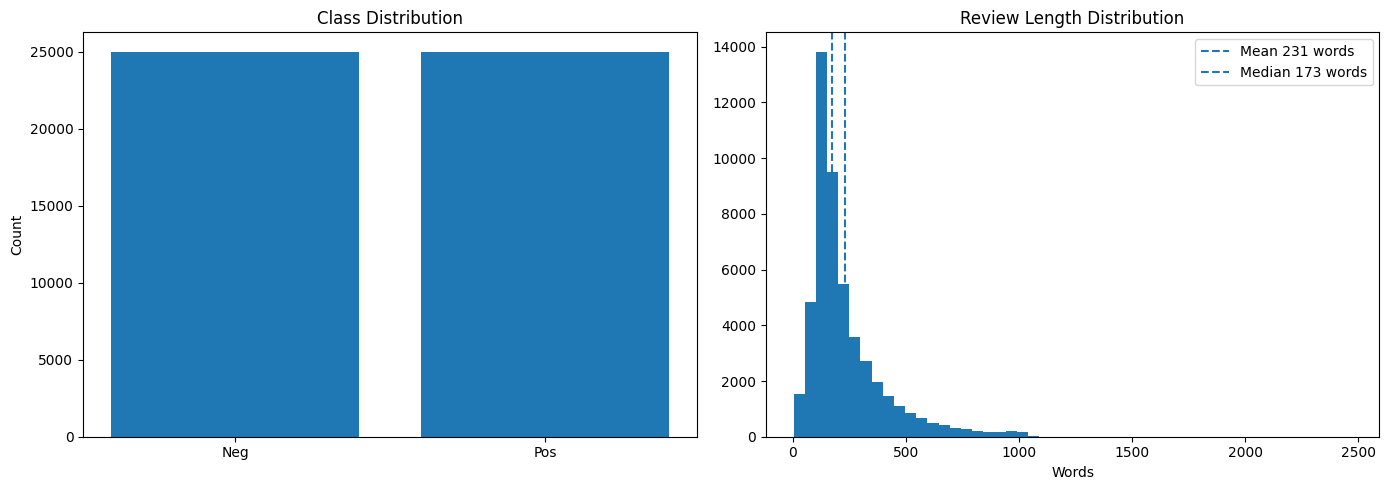


Total Reviews: 50000
Neg: 25000 (50.0%)
Pos: 25000 (50.0%)

Length stats:
Min: 4
Max: 2470
Mean: 231.2
Median: 173.0
Std: 171.3



In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Visualizing how many reviews we have per class and their word counts
counts = np.bincount(y)
lengths = [len(r.split()) for r in x]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
ax[0].bar(range(len(counts)), counts)
ax[0].set_xticks(range(len(counts)))
ax[0].set_xticklabels(['Neg', 'Pos'])
ax[0].set_title("Class Distribution")
ax[0].set_ylabel("Count")

# Review length distribution
ax[1].hist(lengths, bins=50)
ax[1].axvline(np.mean(lengths), linestyle="--", label=f"Mean {np.mean(lengths):.0f} words")
ax[1].axvline(np.median(lengths), linestyle="--", label=f"Median {np.median(lengths):.0f} words")
ax[1].set_title("Review Length Distribution")
ax[1].set_xlabel("Words")
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"""
Total Reviews: {len(x)}
Neg: {counts[0]} ({counts[0]/len(x)*100:.1f}%)
Pos: {counts[1]} ({counts[1]/len(x)*100:.1f}%)

Length stats:
Min: {min(lengths)}
Max: {max(lengths)}
Mean: {np.mean(lengths):.1f}
Median: {np.median(lengths):.1f}
Std: {np.std(lengths):.1f}
""")

Here, we split our dataset. First, we give 10% to test set and 90% to train and development set, and finally we split the 90% of train+dev into 20% to dev and 70% on train. So, that means that we have 72% on train, 18% on development and 10% on test subsets.
As a result, we have 36000 for train, 9000 for validation and 5000 for test.


In [12]:
# First, we split the total data: 90% stays for training/validation and 10% is set aside for the final test
X_temp, X_test, y_temp, y_test = train_test_split(
    x, y, test_size=0.1,
    random_state=42
)

# Then, we take that 90% (X_temp) and split it again:
# 80% for the actual training and 20% for validation (tuning)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2,
    stratify=y_temp,
    random_state=42
)

# Printing the final sizes to confirm the split worked
print(f"train: {len(X_train)}, val: {len(X_val)}, test: {len(X_test)}")

train: 36000, val: 9000, test: 5000


In [13]:
print(f'Number of training examples: {len(X_train)}')
print(f'Categories: {np.unique(y_train)}') # print the categories, we have binary classification problem

Number of training examples: 36000
Categories: [0 1]


In [14]:
avg_length = int(np.mean([len(re.sub(r'[^a-zA-Z]', ' ', text.lower()).split()) for text in X_train]))


In [15]:
print(f'Training corpus average text length: {avg_length}')


Training corpus average text length: 238


We define the function clean_text with argument text and we apply all the above:
1. Convert all letters to lowercase
2. Remove HTML tags
3. Remove underscores
4. Remove special characters
5. Remove numbers
6. Remove extra whitespaces

In [16]:
def clean_text(text):

  if not isinstance(text, str):
    return ""


  # Convert to lowercase
  text = text.lower()

  # Remove HTML tags
  text = re.sub(r'<[^>]*>', '', text)



  # Remove underscores
  text = re.sub(r'_', ' ', text)

  # Remove special characters
  text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

  # Remove numbers
  text = re.sub(r'\d+', '', text)



  # Remove extra whitespaces
  text = re.sub(r'\s+', ' ', text).strip()

  return text

Now, we define the tokenize function, that remove all the useless english words, with **stopwords**, we call clean_text function that we apply before to clean the text, after that we split the text into sentences with **sent_tokenize** and finally we split the sentences into words with **word_tokenize**

In [17]:
def tokenize(data):



    # Stopwords
    stop_words = stopwords.words('english')
    stop_words.extend(string.punctuation)

    # Add custom stopwords for movie reviews
    stop_words.extend([
        'the', 'of', 'and', 'as', 'a', 'to', 'in', 'on', 'for',
        'film', 'movie', 'watch', 'seen', 'time'
    ])

    tokenized_samples = []

    for sample in data:
        # Clean the text
        cleaned_text = clean_text(sample)

        if  cleaned_text:
            tokens = []

            # Split into sentences
            sentences = sent_tokenize(cleaned_text)

            for sent in sentences:
               # Tokenize into words
               words = word_tokenize(sent)

               for word in words:
                   # Filter stopwords
                   if word.lower() not in stop_words and word.strip():
                      tokens.append(word.lower())
               if tokens:
                  tokenized_samples.append(tokens)


    return tokenized_samples


We make sure that all our data (Train, Val, and Test) is processed in the exact same way. By tokenizing once and saving the results into these variables, we don't have to keep re-processing the raw text every time we want to try a different model.

In [18]:
X_train_tokenized = tokenize(X_train)
X_val_tokenized = tokenize(X_val)
X_test_tokenized = tokenize(X_test)

### Data Post-Processing: Tokens to Text
We use the function **tokens_to_text** which convert tokens back to text, which is often a necessary step before vectorization.
The function **tokens_to_text** iterates through a list of tokenized documents and joins the individual words back into single strings.
The function is applied to each subset (train, validation, test).
Then, it calculates the average number of tokens per document, since it helps us to identify if the preprocessing was agressive.
Finally, we print the original text and the processed text and the first 15 tokens of the tokenized train set to see if it works well.

In [19]:
# Convert tokens back to text
def tokens_to_text(token_lists):
    """Convert list of token lists to list of text strings"""
    text_strings = []
    for tokens in token_lists:
      if tokens: # Only if tokens exist
         text = ' '.join(tokens)  # Join tokens with space
         text_strings.append(text)
      else:
        text_strings.append('') # Empty string if no tokens
    return text_strings

# Apply to all datasets

print(" Converting tokens back to text...")
X_train_processed = tokens_to_text(X_train_tokenized)
X_val_processed = tokens_to_text(X_val_tokenized)
X_test_processed = tokens_to_text(X_test_tokenized)


print(f"X_train_processed: {len(X_train_processed)} texts")
print(f"X_val_processed: {len(X_val_processed)} texts")
print(f"X_test_processed: {len(X_test_processed)} texts")

avg_train = np.mean([len(t) for t in X_train_tokenized if t])
avg_val = np.mean([len(t) for t in X_val_tokenized if t])
avg_test = np.mean([len(t) for t in X_test_tokenized if t])

print(f"\nAverage tokens per document:")
print(f"  Train: {avg_train:.0f}")
print(f"  Val: {avg_val:.0f}")
print(f"  Test: {avg_test:.0f}")

print(f"\nOriginal text (first 200 chars):")
print(X_train[0][:200])

print(f"\nProcessed text (first 200 chars):")
print(X_train_processed[0][:200])


print(f"\nFirst 15 tokens:")
print(X_train_tokenized[0][:15])

 Converting tokens back to text...
X_train_processed: 36000 texts
X_val_processed: 9000 texts
X_test_processed: 5000 texts

Average tokens per document:
  Train: 114
  Val: 114
  Test: 116

Original text (first 200 chars):
*Warning! Some spoilers!*<br /><br />Matt, a rich writer, is in fact still just a boy in his behaviour. He doesn't care about anyone's but his own needs and couldn't care less about the consequences o

Processed text (first 200 chars):
warning spoilersmatt rich writer fact still boy behaviour doesnt care anyones needs couldnt care less consequences actions gets know nimi bonds familiy communitiy starts feel something missing livehe 

First 15 tokens:
['warning', 'spoilersmatt', 'rich', 'writer', 'fact', 'still', 'boy', 'behaviour', 'doesnt', 'care', 'anyones', 'needs', 'couldnt', 'care', 'less']


We use **CountVectorizer** to identify the most frequent words in our training set. We set a limit at the vocabulary at the top 5000 words to keep the model efficient.
We create a new dictionary (vocab). It reserves index 0 for <PAD> and index 1 for <UNK>, shifting all other word indices by 2.
Then, we download **word2vec**, which contains 300-dimensional vectors for millions of words. We create the **embedding matrix**, which has the size of the word2vec.vector size. It is logical that not every word of the 5000 will exist in the word2vec dataset, so what we do is that if the word exists in word2vec then we take the corresponding embedding of this word, else if the word is not exists in the word2vec we assigned it to **average_embedding** matrix and we can see from the results that 81 words are not exists at the word2vec.
Finally, the final shape of the embedding matrix will be: (Vocab_size + 2, 300)

In [20]:
vectorizer = CountVectorizer(max_features=5000) # create a dict with 5000 words
vectorizer.fit(X_train_processed)
custom_vocab = vectorizer.vocabulary_

print(f"Vocabulary size: {len(custom_vocab)}")

# Load Word2Vec embeddings
word2vec = api.load('word2vec-google-news-300')

# Create embedding matrix
embedding_dim = word2vec.vector_size # 300
average_embedding = np.mean(word2vec.vectors, axis=0) # Average all embeddings

# Create vocab dict with PAD and UNK
vocab = {'<PAD>': 0, '<UNK>': 1}
vocab.update({word: idx + 2 for idx, word in enumerate(custom_vocab)})


# Create embedding matrix
embedding_matrix = np.zeros((len(vocab), embedding_dim))

# PAD token embedding (zeros)
embedding_matrix[0] = np.zeros(embedding_dim)

# UNK token embedding (average)
embedding_matrix[1] = average_embedding

# Fill embedding matrix for all other words
oov_count = 0 # Out-Of-Vocabulary counter


for word, idx in vocab.items():
  if word in word2vec.key_to_index: # Check if the word exists in Word2Vec
    embedding_matrix[idx] = word2vec[word] # Take the corresponding embedding of the word
  else: # For words not in Word2Vec except from the tokens  PAD and UNK
    embedding_matrix[idx] = average_embedding
    oov_count += 1





#Clean up memory
del word2vec

print(f"\nSummary:")
print(f" Final Vocabulary size: {len(vocab)}")
print(f"  Embedding dim: {embedding_dim}")
print(f"  Embedding matrix shape: {embedding_matrix.shape}")
print(f"  OOV words: {oov_count} ({100*oov_count/len(vocab):.2f}%)")

Vocabulary size: 5000
[==================================================] 100.0% 1662.8/1662.8MB downloaded

Summary:
 Final Vocabulary size: 5002
  Embedding dim: 300
  Embedding matrix shape: (5002, 300)
  OOV words: 82 (1.64%)


### Text to IDs
Models cannot multiply a word, they require a unique integer representation for every token. We create an empty list with the name sequences, and for every text in texts we split it into words and then convert each word to its IDs. For every word  if the word exists in vocabulary then we add the known word to the list of ids and if the word is <UNK> then we add the <UNK> (with index 1) token also to ids list and finally we append the ids list to the initial sequences list.
Finally, we apply the **text_to_ids** function to all sets.
Also, we calculate the Average Sequence Length, because it will helps us with the Padding after.

In [21]:
def text_to_ids(texts, vocab):
  """
  Convert text documents to sequences of word IDs
  text: List of text strings
  vocab: Dictionary mapping words to IDs
  Return: List of sequences, each sequence is a list of word IDs
  """

  sequences = []

  for text in texts:
    # Split text into words
    words = text.split()

    # Convert each word to its IDs
    ids = []
    for word in words:
      if word in vocab:
        ids.append(vocab[word]) # Known word
      else:
        ids.append(vocab['<UNK>']) # Unknown word -> UNK token
    sequences.append(ids)

  return sequences



# Apply to all datasets

X_train_ids = text_to_ids(X_train_processed, vocab)

X_val_ids = text_to_ids(X_val_processed, vocab)

X_test_ids = text_to_ids(X_test_processed, vocab)


print(f"\nDataset sizes:")
print(f"  X_train_ids: {len(X_train_ids)} sequences")
print(f"  X_val_ids: {len(X_val_ids)} sequences")
print(f"  X_test_ids: {len(X_test_ids)} sequences")


# Average sequence length
avg_train_len = np.mean([len(seq) for seq in X_train_ids])
avg_val_len = np.mean([len(seq) for seq in X_val_ids])
avg_test_len = np.mean([len(seq) for seq in X_test_ids])


print(f"\nAverage sequence length (in word IDs):")
print(f"  Train: {avg_train_len:.0f}")
print(f"  Val: {avg_val_len:.0f}")
print(f"  Test: {avg_test_len:.0f}")

print("EXAMPLE: Text → Word IDs")
print("="*80)

print(f"\nOriginal text:")
print(f"  {X_train_processed[0][:100]}...")

print(f"\nWord IDs:")
print(f"  {X_train_ids[0][:20]}...")





Dataset sizes:
  X_train_ids: 36000 sequences
  X_val_ids: 9000 sequences
  X_test_ids: 5000 sequences

Average sequence length (in word IDs):
  Train: 114
  Val: 114
  Test: 116
EXAMPLE: Text → Word IDs

Original text:
  warning spoilersmatt rich writer fact still boy behaviour doesnt care anyones needs couldnt care les...

Word IDs:
  [2, 1, 3, 4, 5, 6, 7, 8, 9, 10, 1, 11, 12, 10, 13, 14, 15, 16, 17, 1]...


### Sequence length distribution
The code calculates the mean,the median and the max of the lengths of our documents. We choose MAX_LEN = 250, because its more than  the double of the mean value and we ensure that we will not cut off many information from the dataset.

In [ ]:
train_lengths = np.array([len(seq) for seq in X_train_ids])

print(train_lengths)
print("Train lengths:")
print(" Mean:", train_lengths.mean())
print(" Median:", np.median(train_lengths))

print(" Max:", train_lengths.max())

MAX_LEN = 250

print("Chosen MAX_LEN:", MAX_LEN)

[172  79 401 ... 260 270  82]
Train lengths:
 Mean: 114.29813888888889
 Median: 85.0
 Max: 1133
Chosen MAX_LEN: 250


With the function **pad_truncate**, we initiate MAX_LEN = 250, so if the document is shorter than 250 words, the function fills the remaining slots with 0 (<PAD> token). If a document has more than 250 words, then the function slices the sequence, keeping only the first 250 words and discarding the rest.

In [23]:
MAX_LEN = 250
PAD_IDX = 0

def pad_truncate(sequences, max_len, pad_value=0):
  """
  sequences: list of lists of word IDs sequences
  max_len: fixed sequence length
  pad_value: 0
  Return: np.array (N, max_len)
  """
  N = len(sequences)
  padded_array = np.full((N, max_len), pad_value, dtype=np.int64)

  for i, seq in enumerate(sequences):
    if not seq: # Empty sequence
      continue
    if len(seq) >= max_len:
      padded_array[i] = np.array(seq[:max_len], dtype=np.int64)
    else:
      padded_array[i, :len(seq)] = np.array(seq, dtype=np.int64)
  return padded_array



Then, we apply **pad_trucate** to each dataset.

In [24]:
# Apply to all datasets
X_train_pad = pad_truncate(X_train_ids, MAX_LEN, PAD_IDX)
X_val_pad = pad_truncate(X_val_ids, MAX_LEN, PAD_IDX)
X_test_pad = pad_truncate(X_test_ids, MAX_LEN, PAD_IDX)

print("Shapes:")
print(f" X_train_pad: {X_train_pad.shape}")
print(f" X_val_pad: {X_val_pad.shape}")
print(f" X_test_pad: {X_test_pad.shape}")

Shapes:
 X_train_pad: (36000, 250)
 X_val_pad: (9000, 250)
 X_test_pad: (5000, 250)


### Creating a Dataset

The **TextDataset** class inherits from torch.utils.data.Dataset and holds the data and provide a standard way to access individual samples. It converts NumPy arrays into torch.long tensors. The function **len** tells PyTorch how many total samples are in the dataset and the function **getitem** alls the model to fetch a single (Features, Label) pair using an index.
The **DataLoader** feeds data to our model during training. Instead of loading all data at once, it provides batching, it groups all the data into sets of 32 samples (**BATCH_SIZE**). This allows the model to update weights more frequently and stay stable. Also, we use **shuffling** in the training set only to ensure the model does not learn the order of the data, preventing overfitting.

In [25]:
# Dataset class
class TextDataset(Dataset):
  def __init__(self,  X_pad, y):
    self.X = torch.tensor(X_pad, dtype=torch.long)
    self.y = torch.tensor(y, dtype=torch.long)

  def __len__(self):
    return len(self.y) # returns the sum of samples at Dataset

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]


BATCH_SIZE = 32


train_dataset = TextDataset(X_train_pad, y_train)
val_dataset = TextDataset(X_val_pad, y_val)
test_dataset = TextDataset(X_test_pad, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True) # 1125
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE) # 282
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)  # 157

In [26]:
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Number of training batches: 1125
Number of validation batches: 282
Number of test batches: 157


### Define the model

The model starts by converting Word IDs into dense vectors. It can load our custom **embedding_matrix**. If **freeze = True**, the pre-trained weights remain static, which is useful when we have a small dataset and want to avoid overfitting. It also uses **padding_idx=0** to ensure that the <PAD> tokens do not contribute to the gradient updates.
We can toggle between three types of RNNs: RNN, GRU, LSTM, Bidirectional. Since the RNN produces an output for every word in our 250-word sequence, the model must summarize these into a single vector before classification, we do it with self-attention. What the attention mechanism do is that passes RNN outputs through a **Linear layer** and a **Tahn activation function**, then it uses **masked_fill** with "-inf" which tells the model to ignore the <PAD> tokens entirely when calculating attention weights. With **softmax** we normalizes the scores so they sum to 1. Finally, according to the weighted sum, multiplies the RNN outputs by these weights to create a single context vector. Then, the summarized context vector passes through **dropout layer** (to prevent overfitting) and finally a **Linear layer** that maps the hidden features to our target classes.

In [ ]:
class RNNModel(nn.Module):
    def __init__(self,
                 vocab_size,
                 embed_dim,
                 hidden_dim,
                 output_dim,
                 attention_dim = None,
                 model_type='LSTM',
                 pretrained=True,
                 freeze=False,
                 num_layers=1,
                 bidirectional=True,
                 use_pooling=False,
                 use_attention=True,
                 dropout=0.3,
                 pretrained_embeddings=None,
                 pad_idx=0):

        super().__init__()
        
        # Store hyperparameters for use in forward pass
        self.use_pooling = use_pooling
        self.use_attention = use_attention
        self.pad_idx = pad_idx

        assert not (use_pooling and use_attention), \
            "Cannot use pooling and attention at the same time"

        if use_attention:
          assert attention_dim is not None, \
              "Attention dimension must be specified"

        scale = 2 if bidirectional else 1

        # Embedding, convert words ids to vectors
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)


        if pretrained and pretrained_embeddings is not None:
          self.embedding.weight.data.copy_(torch.from_numpy(pretrained_embeddings).float()) # copy the pretrained word2vec vectors (embeddings)
          if freeze: # freeze = True, then the pretrained embeddings will not be updated
            self.embedding.weight.requires_grad = False


        # Create the RNN layer
        rnn_class = {'RNN': nn.RNN, 'GRU': nn.GRU, 'LSTM': nn.LSTM}[model_type]
        
        # Create a LSTM layer with the parameters
        self.rnn = rnn_class(embed_dim, hidden_dim, batch_first=True,
                             num_layers=num_layers, bidirectional=bidirectional,
                             dropout=dropout if num_layers > 1 else 0)





        # Compute the Attention weights
        if self.use_attention:
          self.attention_mlp = nn.Sequential(
              nn.Linear(scale * hidden_dim, attention_dim),
              nn.Tanh(),
              nn.Dropout(dropout),
              nn.Linear(attention_dim, 1) # convert attention_dim to 1D (score) 
          )

        # Classification
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(scale * hidden_dim, output_dim)  # linear layer that convert context vector (256D) to logits (2D)


    def forward(self, x):
        # Embedding
        embedded = self.embedding(x)

        # RNN
        output, _ = self.rnn(embedded)


        # aggregation
        if self.use_pooling:
            context = torch.max(output, dim=1).values  # max along all states


        elif self.use_attention:
          scores = self.attention_mlp(output).squeeze(-1)
          padding_mask = (x == self.pad_idx) # shows which tokens are <PAD> 

          # mask padding tokens equal to -inf
          scores = scores.masked_fill(padding_mask, float('-inf'))

          # Softmax normalization
          weights = F.softmax(scores, dim=1)

          # Handle NaN from all-masked sequences
          weights = torch.where(torch.isnan(weights), torch.zeros_like(weights), weights)

          # Weighted sum of hidden states ( take each hidden state and multiply by the attention weights and sum them up)
          context = torch.sum(output * weights.unsqueeze(-1), dim=1)
        else:
          context = output[:, -1, :] # Last token



        # Classification

        logits = self.fc(self.dropout(context)) # (batch_size, output_dim)

        return logits

### Training and Evaluation Functions

The **_unpack_batch** helper function adds flexibility to our pipeline. It ensures that whether our DataLoader returns just features and labels or includes a padding mask (X, mask, y), the training loop can extract what it needs without crashing.
The **train_model** function manages the learning process over several epochs.

We use dynamic learning rate (**ReduceLROnPlateau**): if the validation loss stops improving for 3 epochs, the scheduler cuts the learning rate in half (**factor=0.5**), this helps the model settle into the global minimum of the loss function. Then, we do **early stopping** in order to avoid overfitting, the training stops if the validation loss does not improve for a set of number of epochs (**patience=5**). Then, the function keeps track of the best version of the model, with the lowest validation loss, and reloads it at the end.

After, with the **evaluate_model** function we need to know how the model performs on the Test Set. This function calculates metrics, such as **accuracy, precision, recall, F1-Macro, PR-AUC**. Inside the evaluate_model we apply **torch.softmax(logits, dim=1)** to convert the model's raw scores into probabilities that sum to 1. Then, it uses **.to(device)**, allowing the code to run seamlessly on either CPU or a GPU. It uses **torch.no_grad()** during validation and testing to disable gradient calculations, significantly reducing memory consumption.

In [ ]:
# Helper function

def _unpack_batch(batch):
    """
    Supports:
      (X, y)
      (X, mask, y)
    Returns:
      X, y
    """
    if isinstance(batch, (list, tuple)):
        if len(batch) == 2:
            X, y = batch
            return X, y
        elif len(batch) == 3:
            X, _mask, y = batch  # ignore mask, RNNModel builds pad mask from X internally
            return X, y
    raise ValueError(f"Unexpected batch format with type={type(batch)} and len={len(batch) if hasattr(batch,'__len__') else 'N/A'}")


# Training function

def train_model(model, train_loader, val_loader, criterion, optimizer, device,
                epochs=20, patience=5, save_path=None, verbose=True):

    # The scheduler lowers the learning rate if the validation loss stops improving
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6
    )
    # Initialize lists and variables
    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_state_dict = None
    best_epoch = 0
    wait = 0

    for epoch in range(epochs):

        model.train()
        train_loss = 0.0

        for batch in train_loader:
            X_batch, y_batch = _unpack_batch(batch)
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            logits = model(X_batch)              # forward pass
            loss = criterion(logits, y_batch)    # compute the loss
            loss.backward()                      # backpropagation
            optimizer.step()                     # update the weights

            train_loss += loss.item()            # numerical value of the loss

        train_loss /= len(train_loader)          # average loss per batch
        train_losses.append(train_loss)


        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for batch in val_loader:
                X_batch, y_batch = _unpack_batch(batch)
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                logits = model(X_batch)
                loss = criterion(logits, y_batch)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        if verbose and (epoch % 2 == 0 or epoch == epochs - 1):
            print(f"Epoch: {epoch:4d} / {epochs} | Training Loss: {train_loss:.5f}, Validation Loss: {val_loss:.5f}")



        # Update the learning rate based on current performance
        scheduler.step(val_loss)

        # Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_state_dict = copy.deepcopy(model.state_dict()) # save the best model
            wait = 0
            if save_path is not None:
                torch.save(best_state_dict, save_path)
        else:
            wait += 1
            if wait >= patience:
                if verbose:
                   print(f"Early stopping at epoch {epoch+1}")
                break

    # Return best version
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return train_losses, val_losses, best_state_dict, best_epoch


# Evaluation Function

def evaluate_model(name, model, test_loader, device):
    model.eval()
    y_true_list, y_pred_list, y_score_list = [], [], []

    with torch.no_grad():
        for batch in test_loader:
            X_batch, y_batch = _unpack_batch(batch)
            X_batch = X_batch.to(device)



            logits = model(X_batch)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(logits, dim=1) # get the class with the highest probability

            y_true_list.extend(y_batch.cpu().numpy()) # transfer from GPU to CPU and convert to numpy array
            y_pred_list.extend(preds.cpu().numpy())
            y_score_list.extend(probs.cpu().numpy())

    y_true = np.array(y_true_list)
    y_pred = np.array(y_pred_list)
    y_scores = np.array(y_score_list)


    pr_auc_pos = average_precision_score(y_true, y_scores[:, 1])
    pr_auc_neg = average_precision_score(1 - y_true, y_scores[:, 0])
    pr_auc_macro = 0.5 * (pr_auc_pos + pr_auc_neg)

    # Metrics
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)

    f1_macro = f1_score(y_true, y_pred, average='macro')
    accuracy = accuracy_score(y_true, y_pred)
    precision = report['macro avg']['precision']
    recall = report['macro avg']['recall']

    print(f"{name}: Accuracy={accuracy:.4f}, Precision={precision:.4f}, Recall={recall:.4f}, F1={f1_macro:.4f}")



    return {
        "per_class": report,
        "pr_auc": {"class0": pr_auc_neg, "class1": pr_auc_pos, "macro": pr_auc_macro},
        "f1_macro": f1_macro,
        "accuracy": accuracy,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_scores": y_scores
    }

### Hyper-parameter tuning with Grid Search
We **tune** hyper-parameters. This script systematically tests different architectures to find the best model for our specific dataset.
We use to different options for the **dropout** (controls regularization to prevent overfitting), **num-layers** (determines the depth of the LSTM), **hidden-dim** (the size of the internal memory of RNN), **learning rate** (how quickly the model updates the weights) and **freeze** (whether to keep Word2Vec embeddings static of fine-tune them). While we have 64 possible combinations, the script selects 16 random configurations. For each of the 16 models, the script:
1. Initialize an RNNModel with specific parameters.
2. Trains the model using previously defined **train_model** function.
3. Evaluates performance on Validation Set using **evaluate_model**.
4. Stores all **metrics** (Loss, F1-Macro, Accuracy) for a final comparison.
After the execution of all the epochs, we created a dataframe that sorts the model by **Validation Loss**. The best model is that with the **lowest Validation Loss**.

In [ ]:

# RNN HYPERPARAMETER TUNING - GRID SEARCH


import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import time

print("RNN Hyper-parameter Tuning with Grid Search on Dev Set")
print("="*100 + "\n")

# ========== GRID SEARCH PARAMETERS ==========


GRID_PARAMS = {
    "dropout": [0.5, 0.7],              # 2 options
    "num_layers": [1, 2],               # 2 options
    "hidden_dim": [64, 128],            # 2 options
    "attention_dim": [50, 100],         # 2 options
    "lr": [0.0001, 0.0003],             # 2 options
    "freeze": [True, False],            # 2 options
}




# SELECT TOP COMBINATIONS

from itertools import product

# Generate all combinations
all_combinations = list(product(*GRID_PARAMS.values()))
param_names = list(GRID_PARAMS.keys())

# Shuffle
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

random.shuffle(all_combinations)
selected_combinations = all_combinations[:16]  

# Create CONFIGS dictionary
CONFIGS = {}
for idx, combo in enumerate(selected_combinations, 1):
    config_name = f"Model_{idx}"
    config_dict = dict(zip(param_names, combo))
    CONFIGS[config_name] = config_dict

print(f"Grid Search: {len(CONFIGS)} configurations (out of {len(all_combinations)} possible)\n")
print("Selected Configurations:")
for name, config in CONFIGS.items():
    print(f"  {name}: {config}")
print("\n")

# ========== CONSTANTS ==========

VOCAB_SIZE = len(vocab)
EMBED_DIM = embedding_matrix.shape[1]
OUTPUT_DIM = 2
BIDIRECTIONAL = True
EPOCHS = 15
PATIENCE = 3
PAD_IDX = 0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE} | Vocab: {VOCAB_SIZE} | Embed Dim: {EMBED_DIM}")
print(f"Epochs: {EPOCHS} | Patience: {PATIENCE}")
print(f"Testing {len(CONFIGS)} configurations...\n")

# RESULTS STRUCTURES

results = {}
best_overall = {
    "key": None,
    "val_loss": float("inf"),
    "f1_macro": -1.0,
    "state_dict": None,
    "best_epoch": None,
    "config": None,
}

# TUNING LOOP

start_time = time.time()

for model_idx, (model_name, config) in enumerate(CONFIGS.items(), 1):

    elapsed = time.time() - start_time
    print(f"[{model_idx}/{len(CONFIGS)}] Training {model_name}... (Elapsed: {elapsed/60:.1f} min)")



    model = RNNModel(
        vocab_size=VOCAB_SIZE,
        embed_dim=EMBED_DIM,
        hidden_dim=config["hidden_dim"],
        output_dim=OUTPUT_DIM,
        attention_dim=config["attention_dim"],
        model_type="LSTM",
        pretrained=True,
        freeze=config["freeze"],
        num_layers=config["num_layers"],
        bidirectional=BIDIRECTIONAL,
        use_attention=True,
        dropout=config["dropout"],
        pretrained_embeddings=embedding_matrix,
        pad_idx=PAD_IDX
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config["lr"])

    # Train
    train_losses, val_losses, best_state_dict, best_epoch = train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        DEVICE,
        epochs=EPOCHS,
        patience=PATIENCE,
        save_path=None,
        verbose=True
    )

    best_val_loss = float(np.min(val_losses))

    # Evaluate the best checkpoint
    model.load_state_dict(best_state_dict)
    eval_results = evaluate_model(model_name, model, val_loader, DEVICE)

    # Store results
    results[model_name] = {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "config": config,
        "state_dict": best_state_dict,
        "f1_macro": eval_results["f1_macro"],
        "accuracy": eval_results["accuracy"],
        "precision": eval_results["per_class"]["macro avg"]["precision"],
        "recall": eval_results["per_class"]["macro avg"]["recall"],
    }

    # Track best overall
    if best_val_loss < best_overall["val_loss"]:
        best_overall.update({
            "key": model_name,
            "val_loss": best_val_loss,
            "state_dict": best_state_dict,
            "best_epoch": best_epoch,
            "config": config,
        })

    # Cleanup
    del model, optimizer
    torch.cuda.empty_cache()
    print()

total_time = time.time() - start_time

# SUMMARY TABLE


print("GRID SEARCH RESULTS: ")


summary_data = []
for name, data in results.items():
    summary_data.append({
        "Model": name,
        "Val Loss": round(data["best_val_loss"], 4),
        "F1 Macro": round(data["f1_macro"], 4),
        "Accuracy": round(data["accuracy"], 4),
        "Precision": round(data["precision"], 4),
        "Recall": round(data["recall"], 4),
        "Layers": data["config"]["num_layers"],
        "Hidden": data["config"]["hidden_dim"],
        "LR": data["config"]["lr"],
        "Dropout": data["config"]["dropout"],
        "Freeze": data["config"]["freeze"],
        "Epoch": data["best_epoch"],
    })

df_results = pd.DataFrame(summary_data).sort_values("Val Loss")
print(df_results.to_string(index=False))

print(f"\n\nBest Model: {best_overall['key']}")
print(f"Val Loss: {best_overall['val_loss']:.4f}")
print(f"Best Epoch: {best_overall['best_epoch']}")
print(f"Total Time: {total_time/60:.1f} minutes\n")

# Set best hyper-parameters

BEST_CFG = best_overall["config"]
HIDDEN_DIM = BEST_CFG["hidden_dim"]
NUM_LAYERS = BEST_CFG["num_layers"]
ATTENTION_DIM = BEST_CFG["attention_dim"]
DROPOUT = BEST_CFG["dropout"]
LEARNING_RATE = BEST_CFG["lr"]
FREEZE = BEST_CFG["freeze"]

print(f"Best Hyperparameters:")
print(f"  HIDDEN_DIM = {HIDDEN_DIM}")
print(f"  NUM_LAYERS = {NUM_LAYERS}")
print(f"  ATTENTION_DIM = {ATTENTION_DIM}")
print(f"  DROPOUT = {DROPOUT}")
print(f"  LEARNING_RATE = {LEARNING_RATE}")
print(f"  FREEZE = {FREEZE}\n")



RNN Hyper-parameter Tuning with Grid Search on Dev Set

Grid Search: 16 configurations (out of 64 possible)

Selected Configurations:
  Model_1: {'dropout': 0.5, 'num_layers': 2, 'hidden_dim': 64, 'attention_dim': 100, 'lr': 0.0003, 'freeze': False}
  Model_2: {'dropout': 0.5, 'num_layers': 2, 'hidden_dim': 128, 'attention_dim': 50, 'lr': 0.0001, 'freeze': False}
  Model_3: {'dropout': 0.5, 'num_layers': 1, 'hidden_dim': 64, 'attention_dim': 100, 'lr': 0.0003, 'freeze': False}
  Model_4: {'dropout': 0.5, 'num_layers': 2, 'hidden_dim': 64, 'attention_dim': 100, 'lr': 0.0003, 'freeze': True}
  Model_5: {'dropout': 0.7, 'num_layers': 1, 'hidden_dim': 128, 'attention_dim': 100, 'lr': 0.0001, 'freeze': False}
  Model_6: {'dropout': 0.7, 'num_layers': 1, 'hidden_dim': 64, 'attention_dim': 50, 'lr': 0.0001, 'freeze': False}
  Model_7: {'dropout': 0.5, 'num_layers': 2, 'hidden_dim': 64, 'attention_dim': 50, 'lr': 0.0003, 'freeze': False}
  Model_8: {'dropout': 0.7, 'num_layers': 2, 'hidden_dim

In this block here, we just take the results from the previous stage (fine-tuning) and we sort the models from the lowest to the highest validation loss (model with the lowest validation loss is the best) and also we print and the number of epochs needed to stop.

In [37]:
sorted_runs = sorted(results.items(), key=lambda x: x[1]["best_val_loss"])
print("\n Models by Validation Loss:")
print("="*70)
for i, (name, r) in enumerate(sorted_runs[:16], 1):
    marker = "*" if i == 1 else "  "
    print(f"{i:2d}{marker} {name}")
    print(f"      Val Loss: {r['best_val_loss']:.6f} @ Epoch {r['best_epoch']}")
print("="*70)


 Models by Validation Loss:
 1* Model_1
      Val Loss: 0.285903 @ Epoch 2
 2   Model_5
      Val Loss: 0.286994 @ Epoch 3
 3   Model_14
      Val Loss: 0.287015 @ Epoch 2
 4   Model_3
      Val Loss: 0.287793 @ Epoch 2
 5   Model_10
      Val Loss: 0.287980 @ Epoch 4
 6   Model_6
      Val Loss: 0.289205 @ Epoch 4
 7   Model_8
      Val Loss: 0.293757 @ Epoch 3
 8   Model_16
      Val Loss: 0.294859 @ Epoch 4
 9   Model_7
      Val Loss: 0.295855 @ Epoch 1
10   Model_12
      Val Loss: 0.297427 @ Epoch 11
11   Model_9
      Val Loss: 0.297585 @ Epoch 8
12   Model_13
      Val Loss: 0.299133 @ Epoch 6
13   Model_4
      Val Loss: 0.301394 @ Epoch 9
14   Model_2
      Val Loss: 0.305173 @ Epoch 3
15   Model_15
      Val Loss: 0.307496 @ Epoch 15
16   Model_11
      Val Loss: 0.309909 @ Epoch 14


The function **load_best_model** initializes a new instance of RNN Model. It uses the **best_cfg** dictionary which contains the optimal values ofr **hidden_dim**, **num_layers** and **freeze** discovered during tuning, to ensure the network structure matches the one that yielded the lowest validation loss. The knowledge of the model is stored in its **state_dict**, which is a mapping of each layer to its learned weights tensors. The command **model.load_state_dict()** populates the newly created model with the exact weights from the best-performing epoch of the best-performing configuration. The call to **model.eval()** disables dropout layers so that the full power of the neurons is used for prediction rathen than training and also ensured the model uses the running statistics learned during training rather than the statistics of the current batch (**Batch Normalization**).

In [38]:
def load_best_model():
    """Load and return the best trained model"""
    model = RNNModel(
        vocab_size=VOCAB_SIZE,
        embed_dim=EMBED_DIM,
        hidden_dim=best_cfg["hidden_dim"],
        output_dim=OUTPUT_DIM,
        attention_dim=best_cfg["attention_dim"],
        model_type="LSTM",
        pretrained=True,
        freeze=best_cfg["freeze"],
        num_layers=best_cfg["num_layers"],
        bidirectional=BIDIRECTIONAL,
        use_attention=True,
        dropout=best_cfg["dropout"],
        pretrained_embeddings=embedding_matrix,
        pad_idx=PAD_IDX
    ).to(DEVICE)
    model.load_state_dict(best_overall["state_dict"])
    model.eval()
    return model

The **evaluate_and_print** function disables gradient tracking to speed up computation and save memory (**torch.no_grad()**), also uses **torch.softmax** to get the confidence levels for each class (needed for PR-AUC), uses **torch.argmax** to pick the class with the highest probability and moves tensors back to the CPU and converts them to NumPy arrays to interface with scikit-learn's metrics functions. The function returns a structured Nested Dictionary, which is useful for comparing results between Train, Dev, Test sets.

In [ ]:
def evaluate_and_print(model, loader, set_name, best_name):
    
       
    y_true_list, y_pred_list, y_score_list = [], [], []

    with torch.no_grad():
        for batch in loader:
            X_batch, y_batch = _unpack_batch(batch)
            X_batch = X_batch.to(DEVICE)

            logits = model(X_batch)
            probs = torch.softmax(logits, dim=1)
            preds = torch.argmax(logits, dim=1)

            y_true_list.extend(y_batch.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())
            y_score_list.extend(probs.cpu().numpy())

    y_true = np.array(y_true_list)
    y_pred = np.array(y_pred_list)
    y_scores = np.array(y_score_list)

    # Compute metrics
    pr_auc_pos = average_precision_score(y_true, y_scores[:, 1])
    pr_auc_neg = average_precision_score(1 - y_true, y_scores[:, 0])
    pr_auc_macro = 0.5 * (pr_auc_pos + pr_auc_neg)

    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    accuracy = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')


    print(f"BEST MODEL EVALUATION ON {set_name} SET")
    print(f"{best_name}")
    print("-" * 100)
    print("\nPER-CLASS METRICS:")
    print(f"Class 0 (Negative):")
    print(f"  Precision: {report['0']['precision']:.4f}")
    print(f"  Recall:    {report['0']['recall']:.4f}")
    print(f"  F1:        {report['0']['f1-score']:.4f}")
    print(f"  PR-AUC:    {pr_auc_neg:.4f}")

    print(f"\nClass 1 (Positive):")
    print(f"  Precision: {report['1']['precision']:.4f}")
    print(f"  Recall:    {report['1']['recall']:.4f}")
    print(f"  F1:        {report['1']['f1-score']:.4f}")
    print(f"  PR-AUC:    {pr_auc_pos:.4f}")

    print(f"\nMACRO-AVERAGED METRICS:")
    print(f"  Precision: {report['macro avg']['precision']:.4f}")
    print(f"  Recall:    {report['macro avg']['recall']:.4f}")
    print(f"  F1:        {f1_macro:.4f}")
    print(f"  PR-AUC:    {pr_auc_macro:.4f}")
    print(f"  Accuracy:  {accuracy:.4f}\n")

    # Save results
    results = {
        "class_0": {
            "precision": report['0']['precision'],
            "recall": report['0']['recall'],
            "f1": report['0']['f1-score'],
            "pr_auc": pr_auc_neg
        },
        "class_1": {
            "precision": report['1']['precision'],
            "recall": report['1']['recall'],
            "f1": report['1']['f1-score'],
            "pr_auc": pr_auc_pos
        },
        "macro": {
            "precision": report['macro avg']['precision'],
            "recall": report['macro avg']['recall'],
            "f1": f1_macro,
            "pr_auc": pr_auc_macro,
            "accuracy": accuracy
        }
    }

    return results

In this step we apply the optimal architecture and weights, identified during Grid Search phase to our three data splits. It performs the **Train Set Evaluation**, which shows how well the model learned the training data, if the scores are significantly higher than others, the model may be overfitting. The **Dev Set Evaluation**, which confirms the results seen during hyper-parameter tuning. It ensures that the best model selection was stable. Finally, the **Test Set Evaluation** which represents the model's true performance on completely unseen data.

In [40]:
best_name = best_overall["key"]
best_cfg = best_overall["config"]

# Train Set
best_model = load_best_model()
train_results = evaluate_and_print(best_model, train_loader, "Train", best_name)

# Dev Set
best_model = load_best_model()
val_results = evaluate_and_print(best_model, val_loader, "Dev", best_name)

# Test Set
best_model = load_best_model()
test_results = evaluate_and_print(best_model, test_loader, "Test", best_name)

BEST MODEL EVALUATION ON Train SET
Model_1
----------------------------------------------------------------------------------------------------

PER-CLASS METRICS:
Class 0 (Negative):
  Precision: 0.9433
  Recall:    0.9091
  F1:        0.9259
  PR-AUC:    0.9777

Class 1 (Positive):
  Precision: 0.9123
  Recall:    0.9454
  F1:        0.9286
  PR-AUC:    0.9760

MACRO-AVERAGED METRICS:
  Precision: 0.9278
  Recall:    0.9272
  F1:        0.9272
  PR-AUC:    0.9769
  Accuracy:  0.9273

BEST MODEL EVALUATION ON Dev SET
Model_1
----------------------------------------------------------------------------------------------------

PER-CLASS METRICS:
Class 0 (Negative):
  Precision: 0.9006
  Recall:    0.8575
  F1:        0.8785
  PR-AUC:    0.9519

Class 1 (Positive):
  Precision: 0.8641
  Recall:    0.9054
  F1:        0.8842
  PR-AUC:    0.9479

MACRO-AVERAGED METRICS:
  Precision: 0.8823
  Recall:    0.8814
  F1:        0.8814
  PR-AUC:    0.9499
  Accuracy:  0.8814

BEST MODEL EVALUATIO

### Loss Curves Visualization

1. **Training Loss**: Represents how well the model is fitting the training data. This should almost always go down.
2. **Validation Loss**: Represents how well the model generalizes to new data.
3. **Red Star**: Marks the best Epoch, the exact moment where validation loss was at its absolute minimum.
4. **Vertical Dotted Line**: Visualizes where the Early Stopping logic would have triggered or where the model's weights were frozen for the final save.

By looking at these curves, the ideal is both lines decrease and stabilize close to each other, that means the model is well-tuned.
If training loss drops and validation loss stars rising again, then the model is memorizing noise, so we should increase dropout (**Overfitting**).
The last case is when both lines stay high or flat, then the model is not complex enough and we should increase hidden_dim or learning rate (**Underfitting**).


Plotting Loss Curves - 16 Grid Search Models



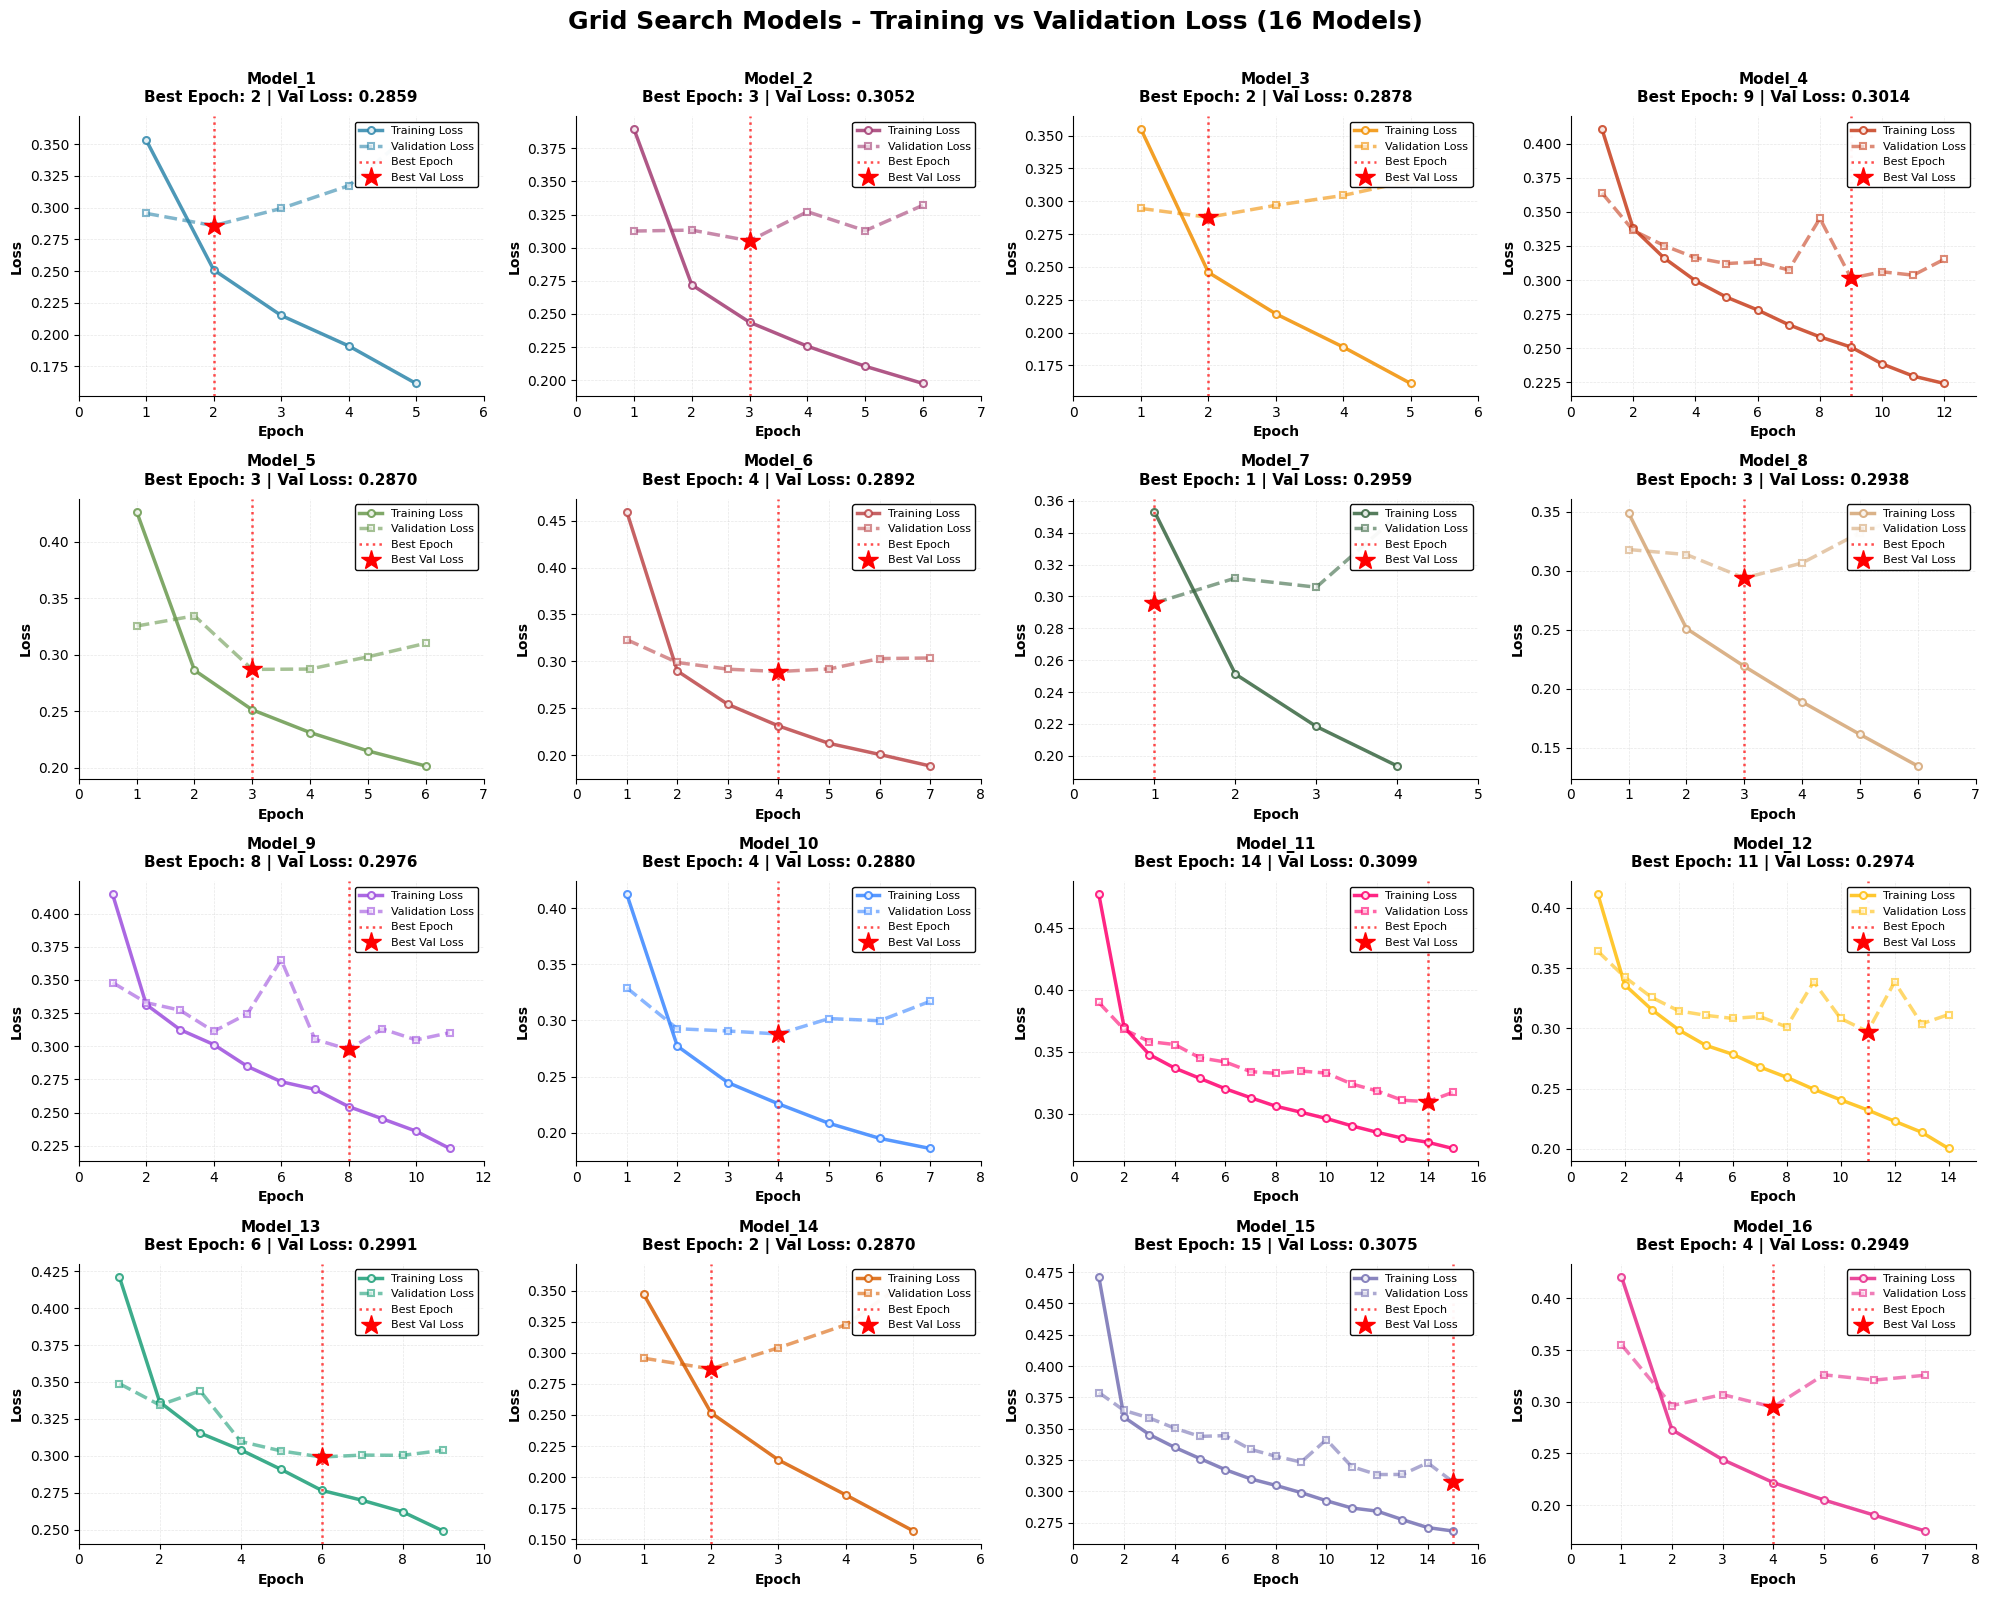

In [43]:

# PLOT TRAINING AND VALIDATION LOSS CURVES





print("Plotting Loss Curves - 16 Grid Search Models")
print("="*100 + "\n")

# Create figure with subplots (4 rows x 4 cols for 16 models)
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

model_names = ["Model_1", "Model_2", "Model_3", "Model_4", "Model_5", "Model_6",
               "Model_7", "Model_8", "Model_9", "Model_10", "Model_11", "Model_12",
               "Model_13", "Model_14", "Model_15", "Model_16"]

colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4749',
          '#386641', '#D4A574', '#9D4EDD', '#3A86FF', '#FF006E', '#FFBE0B',
          '#1B9E77', '#D95F02', '#7570B3', '#E7298A']

# Plot each model
for idx, model_name in enumerate(model_names):
    ax = axes[idx]

    # Check if model exists in results
    if model_name not in results:
        ax.text(0.5, 0.5, f'{model_name}\nNo data',
               ha='center', va='center', fontsize=11, fontweight='bold',
               transform=ax.transAxes, color='gray')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        continue

    train_losses = results[model_name]["train_losses"]
    val_losses = results[model_name]["val_losses"]
    best_epoch = results[model_name]["best_epoch"]
    best_val_loss = results[model_name]["best_val_loss"]

    # Plot curves
    epochs_range = range(1, len(train_losses) + 1)
    ax.plot(epochs_range, train_losses, label='Training Loss', marker='o', linewidth=2.5,
            markersize=5, color=colors[idx], alpha=0.85, markerfacecolor='white', markeredgewidth=1.5)
    ax.plot(epochs_range, val_losses, label='Validation Loss', marker='s', linewidth=2.5,
            markersize=5, color=colors[idx], alpha=0.6, linestyle='--',
            markerfacecolor='white', markeredgewidth=1.5)

    # Mark best epoch
    ax.axvline(x=best_epoch, color='red', linestyle=':', linewidth=1.8, alpha=0.7, label='Best Epoch')
    ax.plot(best_epoch, best_val_loss, 'r*', markersize=15, zorder=5, label='Best Val Loss')

    # Formatting
    ax.set_xlabel('Epoch', fontsize=10, fontweight='bold')
    ax.set_ylabel('Loss', fontsize=10, fontweight='bold')
    ax.set_title(f'{model_name}\nBest Epoch: {best_epoch} | Val Loss: {best_val_loss:.4f}',
                fontsize=11, fontweight='bold', pad=10)

    # Legend
    ax.legend(fontsize=8, loc='upper right', framealpha=0.95, edgecolor='black')

    # Grid
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_axisbelow(True)

    # Axis limits
    ax.set_xlim(0, len(train_losses) + 1)

    # Styling
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_color('lightgray')
    ax.spines['right'].set_color('lightgray')

# Add overall title
fig.suptitle('Grid Search Models - Training vs Validation Loss (16 Models)',
             fontsize=18, fontweight='bold', y=0.995)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()



### Error Analysis: Confusion Matrices

The matrix compares the True_Labels (rows) against the Predicted Labels (columns).
1. **True Negatives** (Top-Left): Correctly identified negative samples.

2. **True Positives** (Bottom-Right): Correctly identified positive samples.

3. **False Positives** (Top-Right): Negative samples misclassified as positive (Type I error).

4. **False Negatives** (Bottom-Left): Positive samples misclassified as negative (Type II error).

Looking at the provided confusion matrices of model 1, we can see that the model performs similarly on both classes. In the test set, it correctly identified 2.170 negatives and 2.301 positives. Also, in the test set the model had 333 FP and 196 FN. This suggests the model slightly more likely to mistake a negative review as positive than vice versa.
The dip from 92% from Train to 89% from Test is small. This confirms that the model is not overfitting and has learned general semantic patterns rather that just memorizing training data.

CONFUSION MATRICES
Best Model: Model_1
Val Loss: 0.2859

Computing predictions...



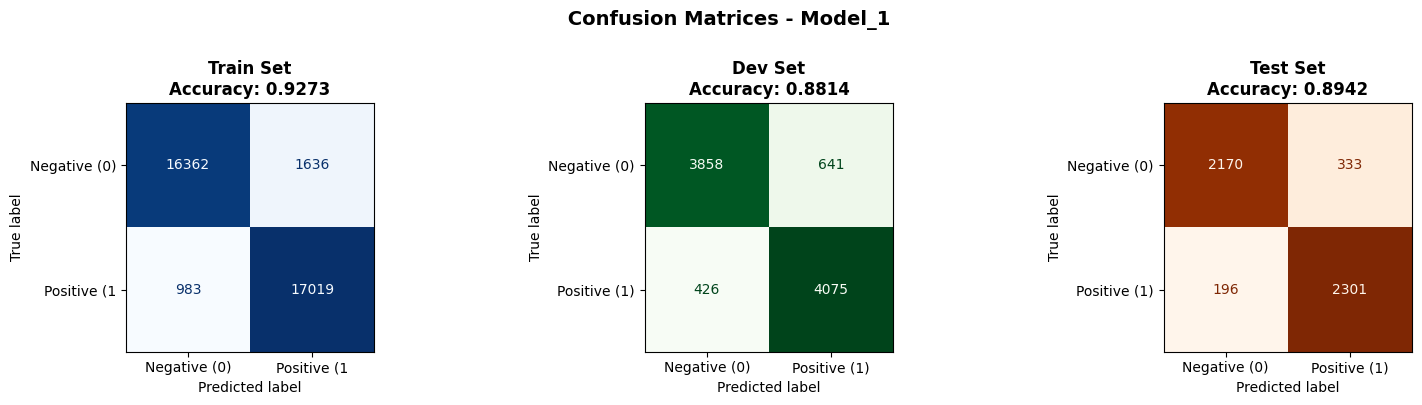

In [44]:

# CONFUSION MATRICES FOR BEST MODEL


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import torch

print("CONFUSION MATRICES")


fig, axes = plt.subplots(1, 3, figsize=(16, 4))

best_name = best_overall["key"]
best_cfg = best_overall["config"]

print(f"Best Model: {best_name}")
print(f"Val Loss: {best_overall['val_loss']:.4f}\n")

# Load best model
best_model = load_best_model()
best_model.eval()

# ========== GET PREDICTIONS FOR ALL SETS ==========

def get_predictions(model, loader):
    """Get y_true and y_pred for a loader"""
    y_true_list, y_pred_list = [], []

    with torch.no_grad():
        for batch in loader:
            X_batch, y_batch = _unpack_batch(batch)
            X_batch = X_batch.to(DEVICE)

            logits = model(X_batch)
            preds = torch.argmax(logits, dim=1)

            y_true_list.extend(y_batch.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())

    return np.array(y_true_list), np.array(y_pred_list)

# Get predictions for all sets
print("Computing predictions...\n")
y_train_true, y_train_pred = get_predictions(best_model, train_loader)
y_val_true, y_val_pred = get_predictions(best_model, val_loader)
y_test_true, y_test_pred = get_predictions(best_model, test_loader)

# ========== TRAIN SET ==========

cm_train = confusion_matrix(y_train_true, y_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=['Negative (0)', 'Positive (1'])
disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False, values_format='d')
axes[0].set_title(f'Train Set\nAccuracy: {np.mean(y_train_true == y_train_pred):.4f}',
                 fontweight='bold', fontsize=12)



# ========== VALIDATION SET ==========

cm_val = confusion_matrix(y_val_true, y_val_pred)
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=['Negative (0)', 'Positive (1)'])
disp_val.plot(ax=axes[1], cmap='Greens', colorbar=False, values_format='d')
axes[1].set_title(f'Dev Set\nAccuracy: {np.mean(y_val_true == y_val_pred):.4f}',
                 fontweight='bold', fontsize=12)



# ========== TEST SET ==========

cm_test = confusion_matrix(y_test_true, y_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Negative (0)', 'Positive (1)'])
disp_test.plot(ax=axes[2], cmap='Oranges', colorbar=False, values_format='d')
axes[2].set_title(f'Test Set\nAccuracy: {np.mean(y_test_true == y_test_pred):.4f}',
                 fontweight='bold', fontsize=12)



# Overall title
fig.suptitle(f' Confusion Matrices - {best_name}',
            fontsize=14, fontweight='bold', y=1.00)

plt.tight_layout()
plt.show()



### Attention Visualization

The code modifies the original RNNModel to create **RNNModelWithAttention**, which returns not only the final prediction (logits) but also the a**ttention weights** for every word in the sequence.

**Green Cells**: Indicate words with high attention scores. These are the words the model deemed most important for determining sentiment (e.g., "like", "rock", "amusing").

**Red Cells**: Indicate words with low attention scores. These are often functional words or noise that the model learned to ignore (e.g., "would", "ten", "even").

The word "rock" has the highest score in your sample ($0.0379$), followed by "like" ($0.0367$). This makes sense for a movie review dataset, as these words carry strong sentiment or topical weight.

The model identified that words like "humor" and "amusing" are relevant, while "year" and "would" are less informative for the final classification.

The scores are calculated using a **Softmax function**, meaning they all sum up to $1$. Even small differences (e.g., $0.03$ vs $0.007$) represent a massive difference in how much the model "listened" to that specific word.

The **forward method** now includes a return_attention flag. When active, it returns the weights tensor after the padding mask has been applied.

To make the heatmap readable, the code uses a **reverse_vocab** to turn the numeric IDs back into the original English words.



Computing predictions and attention weights...

Creating heatmap...

Min attention score: 0.007514
Max attention score: 0.037866



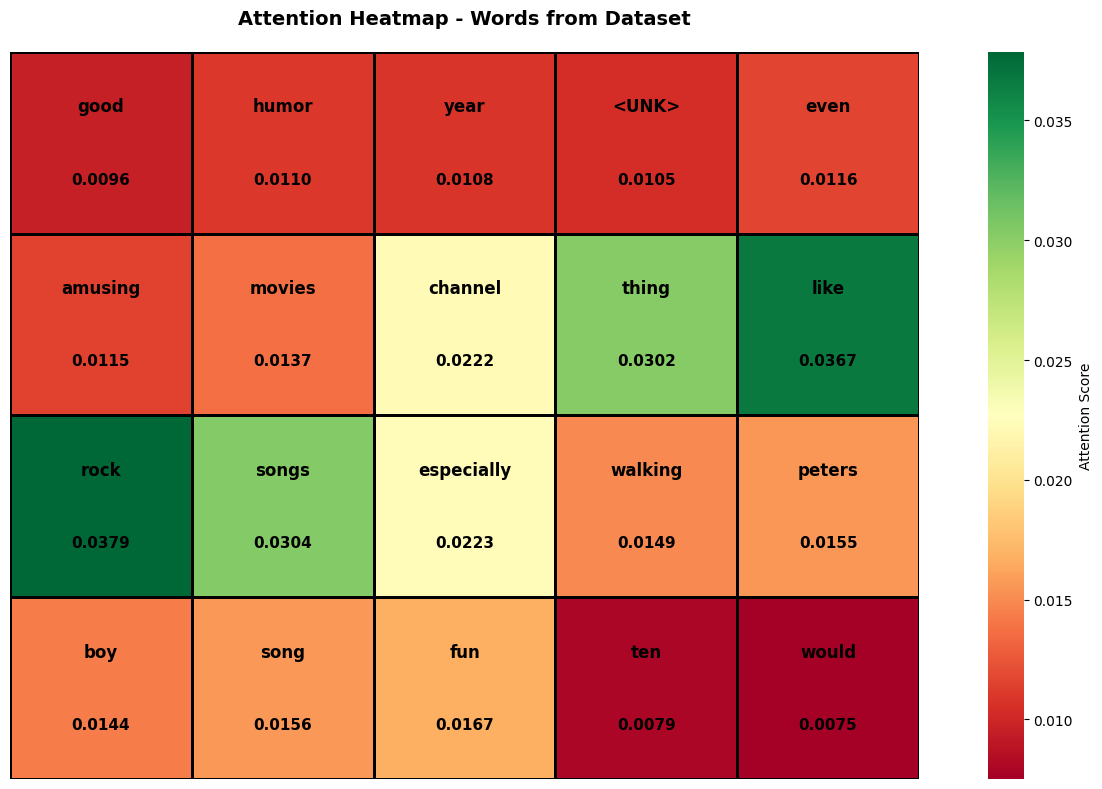

In [ ]:

# ATTENTION HEATMAP


import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#MODIFIED RNNMODEL - WITH ATTENTION RETURN

class RNNModelWithAttention(nn.Module):
    """Modified RNNModel that returns attention weights"""

    def __init__(self,
                 vocab_size,
                 embed_dim,
                 hidden_dim,
                 output_dim,
                 attention_dim=None,
                 model_type='LSTM',
                 pretrained=True,
                 freeze=False,
                 num_layers=1,
                 bidirectional=True,
                 use_pooling=False,
                 use_attention=True,
                 dropout=0.3,
                 pretrained_embeddings=None,
                 pad_idx=0):

        super().__init__()

        self.use_pooling = use_pooling
        self.use_attention = use_attention
        self.pad_idx = pad_idx

        assert not (use_pooling and use_attention), \
            "Cannot use pooling and attention at the same time"

        if use_attention:
            assert attention_dim is not None, \
                "Attention dimension must be specified"

        scale = 2 if bidirectional else 1

        # Embedding
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        if pretrained and pretrained_embeddings is not None:
            self.embedding.weight.data.copy_(torch.from_numpy(pretrained_embeddings).float())
            if freeze:
                self.embedding.weight.requires_grad = False

        # RNN layer
        rnn_class = {'RNN': nn.RNN, 'GRU': nn.GRU, 'LSTM': nn.LSTM}[model_type]

        self.rnn = rnn_class(embed_dim, hidden_dim, batch_first=True,
                             num_layers=num_layers, bidirectional=bidirectional,
                             dropout=dropout if num_layers > 1 else 0)

        # Attention MLP
        if self.use_attention:
            self.attention_mlp = nn.Sequential(
                nn.Linear(scale * hidden_dim, attention_dim),
                nn.Tanh(),
                nn.Dropout(dropout),
                nn.Linear(attention_dim, 1)
            )

        # Classification
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(scale * hidden_dim, output_dim)

    def forward(self, x, return_attention=False):
        # Embedding
        embedded = self.embedding(x)

        # RNN
        output, _ = self.rnn(embedded)

        # Aggregation
        if self.use_attention:
            scores = self.attention_mlp(output).squeeze(-1)
            padding_mask = (x == self.pad_idx)

            # Mask padding tokens
            scores = scores.masked_fill(padding_mask, float('-inf'))

            # Softmax normalization
            weights = F.softmax(scores, dim=1)

            # Handle NaN from all-masked sequences
            weights = torch.where(torch.isnan(weights), torch.zeros_like(weights), weights)

            # Weighted sum
            context = torch.sum(output * weights.unsqueeze(-1), dim=1)

            if return_attention:
                return self.fc(self.dropout(context)), weights
        else:
            context = output[:, -1, :]

        logits = self.fc(self.dropout(context))

        if return_attention and not self.use_attention:
            return logits, None

        return logits if not return_attention else (logits, None)






# Load best model
best_model = load_best_model()

# Create model with attention return
best_model_with_attention = RNNModelWithAttention(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=best_cfg["hidden_dim"],
    output_dim=OUTPUT_DIM,
    attention_dim=best_cfg["attention_dim"],
    model_type="LSTM",
    pretrained=True,
    freeze=best_cfg["freeze"],
    num_layers=best_cfg["num_layers"],
    bidirectional=BIDIRECTIONAL,
    use_attention=True,
    dropout=best_cfg["dropout"],
    pretrained_embeddings=embedding_matrix,
    pad_idx=PAD_IDX
).to(DEVICE)

# Load weights
best_model_with_attention.load_state_dict(best_model.state_dict())
best_model_with_attention.eval()

# GET PREDICTIONS AND ATTENTION

print("Computing predictions and attention weights...\n")

predictions = []
true_labels = []
attention_weights_list = []
review_texts_list = []

with torch.no_grad():
    for batch_idx, batch in enumerate(test_loader):
        X_batch, y_batch = _unpack_batch(batch)
        X_batch = X_batch.to(DEVICE)

        logits, weights = best_model_with_attention(X_batch, return_attention=True)
        preds = torch.argmax(logits, dim=1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(y_batch.cpu().numpy())
        attention_weights_list.extend(weights.cpu().numpy())

        # Store batch X for text decoding
        for x in X_batch.cpu().numpy():
            review_texts_list.append(x)

predictions = np.array(predictions)
true_labels = np.array(true_labels)
attention_weights_list = np.array(attention_weights_list)

# Create reverse vocab
reverse_vocab = {v: k for k, v in vocab.items()}

# Create Heatmap

print("Creating heatmap...\n")

# Select random test example
random_idx = np.random.randint(0, len(attention_weights_list))

# Decode tokens
text_ids = review_texts_list[random_idx]
tokens = [reverse_vocab.get(tid, '<UNK>') for tid in text_ids if tid != PAD_IDX]
attn_scores = attention_weights_list[random_idx][:len(tokens)]

# Remove ALL duplicate tokens (keep only first occurrence of each word)
unique_tokens = []
unique_attn = []
seen_words = set()

for token, score in zip(tokens, attn_scores):
    if token not in seen_words:
        unique_tokens.append(token)
        unique_attn.append(score)
        seen_words.add(token)

# Take 20 words (5x4 grid)
num_cols = 5
num_rows = 4
num_words = num_cols * num_rows

if len(unique_tokens) > num_words:
    # Randomly select num_words
    selected_indices = np.random.choice(len(unique_tokens), size=num_words, replace=False)
    selected_indices = np.sort(selected_indices)
else:
    selected_indices = np.arange(len(unique_tokens))

selected_tokens = [unique_tokens[i] for i in selected_indices]
selected_attn = [unique_attn[i] for i in selected_indices]

# Pad if necessary
while len(selected_tokens) < num_words:
    selected_tokens.append('')
    selected_attn.append(0)

selected_tokens = selected_tokens[:num_words]
selected_attn = selected_attn[:num_words]

# Create matrix in square format (4 rows x 5 cols)
attn_matrix = np.array(selected_attn, dtype=float).reshape(num_rows, num_cols)
word_matrix = np.array(selected_tokens).reshape(num_rows, num_cols)

# Create figure
fig = plt.figure(figsize=(14, 8))
ax = plt.subplot(111)

# Χρησιμοποιούμε το min/max αυτού του heatmap

print(f"Min attention score: {attn_matrix.min():.6f}")
print(f"Max attention score: {attn_matrix.max():.6f}")
print()

# Create heatmap with AUTO color scale
sns.heatmap(attn_matrix,
            xticklabels=False,
            yticklabels=False,
            cmap='RdYlGn',
            cbar_kws={'label': 'Attention Score'},
            ax=ax,
            linewidths=2,
            linecolor='black',
            annot=False,
            square=True,
            cbar=True,
            vmin=attn_matrix.min(),      
            vmax=attn_matrix.max())      

# Add text annotations (words + scores)
for i in range(num_rows):
    for j in range(num_cols):
        word = word_matrix[i, j]
        score = attn_matrix[i, j]

        # Word above
        ax.text(j + 0.5, i + 0.3, word,
               ha='center', va='center',
               fontsize=12, fontweight='bold',
               color='black')

        # Score below
        ax.text(j + 0.5, i + 0.7, f'{score:.4f}',
               ha='center', va='center',
               fontsize=11, fontweight='bold',
               color='black')

ax.set_title('Attention Heatmap - Words from Dataset', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()



### Final Model Comparison

We evaluate the performance of the Best RNN (BiLSTM with attention) against the baseline models and the MLP.

The following table summarizes the metrics achieved on the unseen Test set.


| Model | Accuracy | F1-Macro | Precision | Recall | PR-AUC (Macro) |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Majority Baseline** | 0.4994 | 0.3331 | 0.2497 | 0.5000 | 0.5000 |
| **Logistic Regression** | 0.8440 | 0.8440 | 0.8441 | 0.8440 | 0.9243 |
| **Best MLP** | 0.8938 | 0.8938 | 0.8944 | 0.8938 | **0.9605** |
| **Best RNN** | **0.8942** | **0.8941** | **0.8954** | **0.8942** | 0.9561 |


The proposed RNN model significantly outperforms the simple baselines, achieving a 56% increase in F1-Macro compared to the Majority Baseline. This confirms that the model has successfully learned complex linguistic patterns rather than simple class frequencies.

While the MLP shows similar overall accuracy, the BiLSTM model maintains a slightly higher Precision (0.8954). This suggests that processing text as a sequence helps the model differentiate between subtle sentiment cues that a Bag-of-Words approach might miss.

The model demonstrates excellent stability, with only a marginal difference between the Dev Set (0.8814) and the Test Set (0.8942). This minimal gap proves that the regularization techniques used—specifically Dropout and Early Stopping—effectively prevented overfitting.

Unlike the black box nature of the MLP or Logistic Regression, the Attention Mechanism in the RNN provides transparency. As seen in the generated Heatmaps, the model correctly identifies and weights semantically heavy words (e.g., "rock", "like", "fun") to reach its conclusions.